In [1]:
%pip install numpy
%pip install scipy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import numpy.linalg as linalg
from scipy.integrate import ode
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation

In [9]:
def solve_wave(k: float, spring_count: int, v0: float, A: float, omega: float, phi: float,
               max_t: float, dt: float = 0.01, displaced_count: int = 1
                  ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    def derivatives(t: float, state: np.ndarray) -> np.ndarray:
        x = state[:len(state) // 2]
        v = state[len(state) // 2:]

        F_link = k * (x[1:] - x[:-1])
        a = np.concat([[0], F_link[1:] - F_link[:-1], [0]])
        a[1] += A * np.sin(omega * t + phi)

        derivatives = np.concat([v, a])
        return derivatives

    integrator = ode(derivatives)
    integrator.set_integrator('vode', method='bdf', order=5, 
                         nsteps=3000, rtol=1e-6, atol=1e-8)

    initial_v = np.zeros(spring_count)
    initial_v[1:1 + displaced_count] = v0

    initial_state = np.concat([np.zeros(spring_count), initial_v])
    integrator.set_initial_value(initial_state, 0)

    t_values = [0.0]
    x_values = [initial_state[:len(initial_state) // 2]]
    v_values = [initial_state[len(initial_state) // 2:]]

    while integrator.successful() and integrator.t < max_t:
        state = integrator.integrate(integrator.t + dt)
        t_values.append(integrator.t)
        x_values.append(state[:len(state) // 2])
        v_values.append(state[len(state) // 2:])

    if not integrator.successful():
        print('Integration failed')

    return (np.array(t_values), np.array(x_values), np.array(v_values))

In [10]:
def show_analysis(k: float, spring_count: int, v0: float, A: float, omega: float, phi: float, 
                  max_t: float, delta_t: float, interval: int = 50, show_t = None, displaced_count: int = 1) -> FuncAnimation:
    if show_t is None:
        show_t = max_t

    t, x, v = solve_wave(k, spring_count, v0, A, omega, phi, max_t, delta_t, displaced_count=displaced_count)

    coords = np.arange(len(x[0]))

    fig, ax = plt.subplots(figsize=(12, 8))
    wave, = plt.plot(coords, x[0])
    plt.ylim(-0.5, 0.5)
    plt.grid(True)
    plt.show()

    def update(frame):
        wave.set_data(coords, x[frame])
        return wave,

    anim = FuncAnimation(fig, update, len(x), interval=interval)

    potential_energy = np.sum(k * (x[:, 1:] - x[:, :-1]) ** 2 / 2, axis=1)[:int(show_t / delta_t)]
    kinetic_energy = np.sum(v**2 / 2, axis=1)[:int(show_t / delta_t)]

    plt.figure(figsize=(12, 8))
    plt.plot(t[:int(show_t / delta_t)], potential_energy, label="Потенциальная энергия")
    plt.plot(t[:int(show_t / delta_t)], kinetic_energy, label="Кинетическая энергия")
    plt.plot(t[:int(show_t / delta_t)], potential_energy + kinetic_energy, label="Полная энергия")
    plt.ylim(bottom=0)

    plt.legend()
    plt.grid(True)
    plt.show()

    non_zero_indices, = np.where(np.abs(x[:, -2]) > 1e-10)
    time_unitl_end = non_zero_indices[0] * delta_t

    print((spring_count - 2) / time_unitl_end, np.sqrt(k))

    return anim

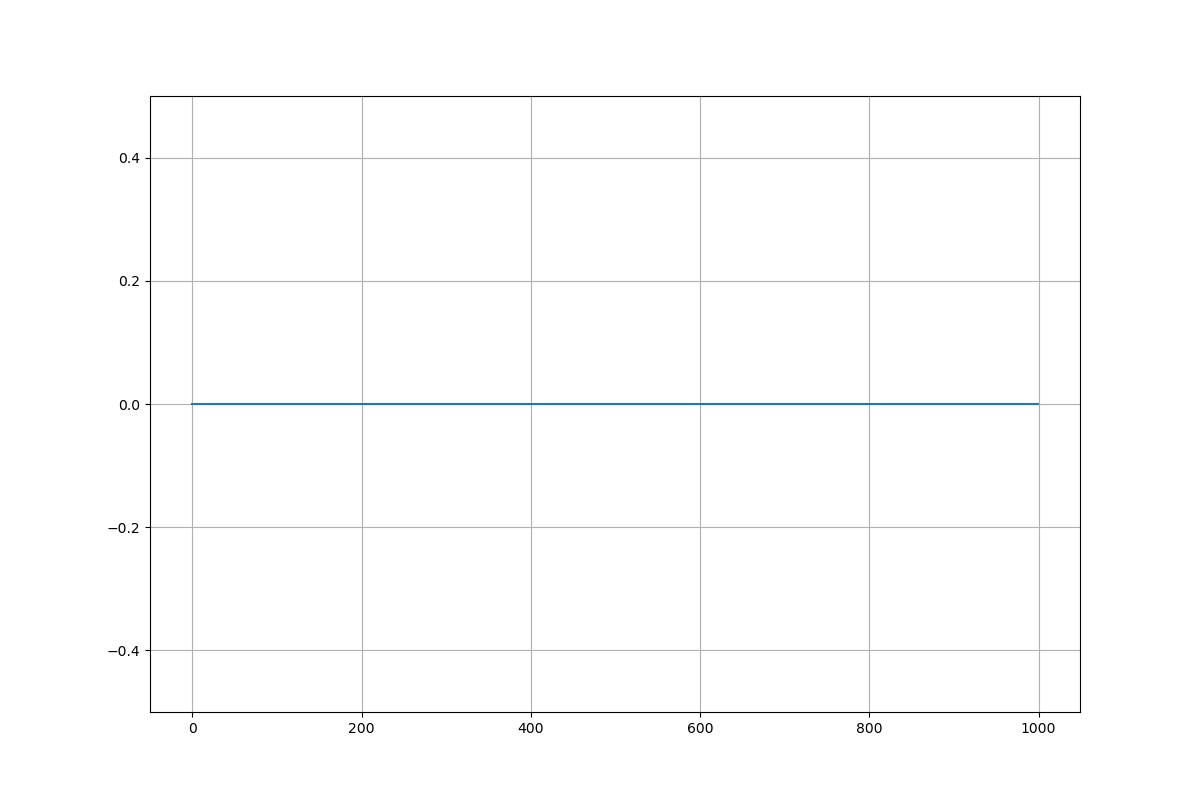

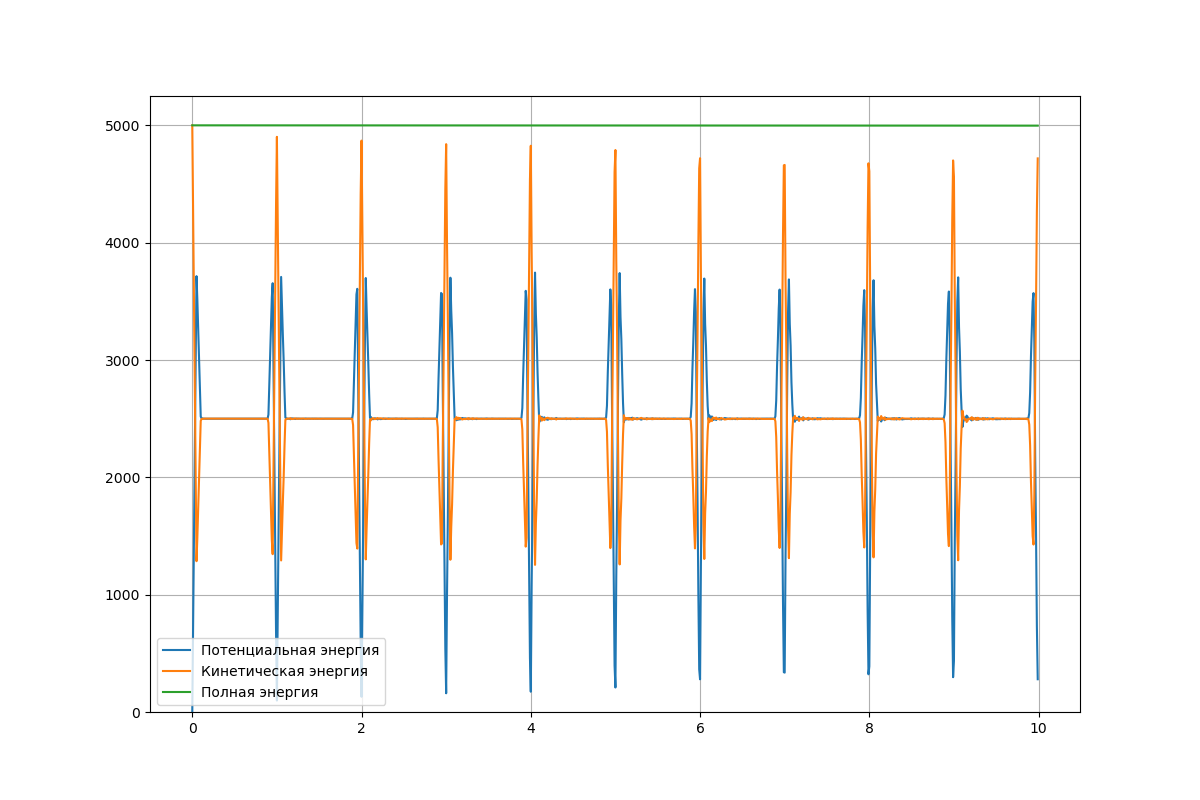

1160.46511627907 1000.0


In [12]:
%matplotlib widget

try:
    anim1.event_source.stop()
except Exception:
    pass

anim1 = show_analysis(1000000, 1000, 10, 0, 0, 0, 10, 0.01, interval=1, displaced_count=100)

In [51]:
%matplotlib widget

try:
    anim2.event_source.stop()
except Exception:
    pass

# anim2 = show_analysis(1000000, 1000, 0, 100000, 20, 0, max_t=3.0, delta_t=0.01, interval=10)

In [53]:
%matplotlib widget

try:
    anim3.event_source.stop()
except Exception:
    pass

K_3 = 1000000
SPRING_COUNT_3 = 500
# anim3 = show_analysis(K_3, SPRING_COUNT_3, 0, 10000, 2 * np.sqrt(K_3) * np.sin(np.pi / 2 / (SPRING_COUNT_3 + 1)) * 4, 0, 10, 0.01, 10)